In [1]:
import pandas as pd
import glob
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import keras.backend as K
from keras.callbacks import Callback
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from keras.regularizers import l2
from sklearn.model_selection import train_test_split

gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1787638842.321198 2465512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787638842.322553 2465512 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787638842.380430 2465512 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787638845.642807 2465512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them 

Num GPUs Available:  0


E0000 00:00:1787638850.270453 2465512 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787638850.270898 2465599 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787638850.357585 2465512 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
# package versions:
# keras                        2.9.0
# matplotlib                   3.5.2
# pandas                       1.4.2
# Pillow                       9.1.1
# scikit-learn                 1.1.2
# scipy                        1.8.1
# tensorflow                   2.9.1

## Params

In [3]:
datapath = "./newdata/"

In [4]:
train_all_polyregmodels = False

In [5]:
# Params for image model
modelname = 'image_val'
use_checkpoint = False
train_new = False

seed = 100

latent_dim = 30
windowsize = 3

decayepochs = 20
decayrate = 0.9
epoch = 500
batchsize = 128

train_size = 8000

modelloc = 'models/' + modelname
checkpoint_path = 'models/checkpoints/' + modelname

In [6]:
# Params for curve model
train_new_curve = False
curveModelName = 'curve_val'

curve_latent_dim = 5
epoch = 500
batchsize = 128

curveModelLoc = "models/curve/" + curveModelName

## Load Data

In [7]:
#load curve data
multiple_data = sorted(glob.glob(datapath + "/CSV_Sat/*.csv"))
print(datapath + "/CSV_Sat/*.csv")

curve_data = pd.read_csv(multiple_data[0])
voltageSeries = np.asarray(curve_data["GateVoltage(V)"])
features = [] #np.zeros(shape = (len(multiple_data),51))
multiple_labels = pd.DataFrame(columns = ['Lg', 'Hpoly', 'Hsub', 'Xj', 'Spacer'])

for i in range(len(multiple_data)):
    #read and save features from filename
    csv_in = multiple_data[i]
    csv_in_features = csv_in.replace("X", ".")
    labelsoup = csv_in_features.partition("CSV_Sat/IdVg_VdSat_n")[2].split('_')

    lg = int(labelsoup[0])
    Hpoly = float(labelsoup[1])
    Hsub = float(labelsoup[2])
    Xj = float(labelsoup[3])
    Spacer = int(labelsoup[4])
    
    if lg >= 25:
        inputarray = np.array([lg, Hpoly, Hsub, Xj, Spacer]).reshape(1, -1)
        inputarray = pd.DataFrame(inputarray.reshape(1,-1), columns=list(multiple_labels))
        multiple_labels = pd.concat([multiple_labels, inputarray], ignore_index=True)

        #read and load curve
        curve_data = pd.read_csv(csv_in)
        curve_data = np.asarray(curve_data["DrainCurrent(A)"])
        #features[i] = curve_data
        features.append(curve_data)
        
features = np.asarray(features)
features = np.log(features)

#final outputs
curve_features = features
curve_labels = multiple_labels

print(len(curve_labels))

./newdata//CSV_Sat/*.csv


/tmp/ipykernel_2465512/2056970589.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  multiple_labels = pd.concat([multiple_labels, inputarray], ignore_index=True)


8755


In [8]:
#Load images
input_dim = 80 #current crop (unscaled) is 290x290


multiple_labels = pd.DataFrame(columns = ['Lg', 'Hpoly', 'Hsub', 'Xj', 'Spacer'])
multi_test_features = []
labelsoup = ""
multiple_data = sorted(glob.glob(datapath + "/Multiple_new_color_thick_lines/*.png"))

for image in multiple_data:
    #extract dims from filename
    image_num = image.replace("X",".")
    labelsoup = image_num.partition("Multiple_new_color_thick_lines/n")[2].split('_')
    lg = int(labelsoup[0])
    Hpoly = float(labelsoup[1])
    Hsub = float(labelsoup[2])
    Xj = float(labelsoup[3])
    Spacer = int(labelsoup[4].partition('.png')[0])
    
    if lg >= 25:
        #write features
        inputarray = np.array([lg, Hpoly, Hsub, Xj, Spacer]).reshape(1, -1)
        inputarray = pd.DataFrame(inputarray.reshape(1,-1), columns=list(multiple_labels))

        #convert image
        bwimage = np.asarray(Image.open(image).convert('L').crop((75,60,365,350)).resize((input_dim,input_dim)))
        bwimage = np.expand_dims(bwimage, -1).astype('float32') /255

        #insert image
        multiple_labels = pd.concat([multiple_labels, inputarray])
        multi_test_features.append(bwimage)

multi_test_features = np.asarray(multi_test_features)
multiple_labels = multiple_labels.reset_index()

#final outputs
image_labels = multiple_labels.drop('index', axis = 1)
image_features = multi_test_features

print(len(image_labels))

/tmp/ipykernel_2465512/2611036035.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  multiple_labels = pd.concat([multiple_labels, inputarray])


8783


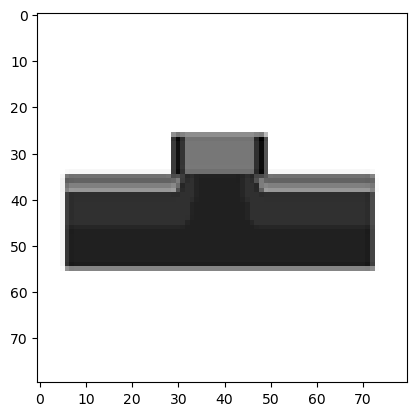

In [13]:

plt.imshow(image_features[3], cmap = 'gray')

## init code for models